# Text classification Spam Detection with CNN, RNN

## 1. Data Preprocessing

In [1]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.layers import LSTM, Embedding
from tensorflow.keras.models import Model

In [3]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1') # encoding needed otherwise error raise, because some varchar exist

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# drop garbage columns
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [6]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.shape

(5572, 2)

In [8]:
# rename columns
df.columns = ['labels', 'data']

In [9]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# create binary labels (0 and 1)
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1}) # create new column as 'b_labels'
y = df['b_labels'].values

In [11]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [12]:
df

,labels,data,b_labels
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will Ì_ b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [13]:
# split the data
x_train, x_test, y_train, y_test = train_test_split(df['data'], y, test_size=0.33)

In [14]:
# Convert sentences to sequences
max_vocab_size = 20000
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(x_train)
sequences_train = tokenizer.texts_to_sequences(x_train)
sequences_test = tokenizer.texts_to_sequences(x_test)

In [15]:
x_train

1279    Waiting 4 my tv show 2 start lor... U leh stil...
5555    Yeh. Indians was nice. Tho it did kane me off ...
2384                               Sorry, I'll call later
3506                 Two fundamentals of cool life: \Walk
2078                       85233 FREE>Ringtone!Reply REAL
                              ...                        
155                          Aaooooright are you at work?
1015    Dear,regret i cudnt pick call.drove down frm c...
30      Wait that's still not all that clear, were you...
1625    Hi Dear Call me its urgnt. I don't know whats ...
3194    Great. P diddy is my neighbor and comes for to...
Name: data, Length: 3733, dtype: object

In [16]:
sequences_train[0]

[238, 44, 10, 417, 550, 20, 318, 90, 6, 418, 85, 760, 150, 35, 1763]

In [17]:
len(sequences_train[0])

15

In [18]:
len(sequences_train[1])

38

In [19]:
# Check word index mapping (to check the number of words in vocabulary)
word2idx = tokenizer.word_index
V = len(word2idx)
print('Total number of unique tokens are: %s' % V)

Total number of unique tokens are: 7299


In [20]:
print(word2idx)

{'i': 1, 'to': 2, 'you': 3, 'a': 4, 'the': 5, 'u': 6, 'and': 7, 'in': 8, 'is': 9, 'my': 10, 'me': 11, 'your': 12, 'for': 13, 'it': 14, 'of': 15, 'have': 16, 'on': 17, 'call': 18, 'that': 19, '2': 20, 'now': 21, 'are': 22, 'so': 23, 'do': 24, 'not': 25, 'but': 26, 'be': 27, 'can': 28, 'at': 29, 'will': 30, 'or': 31, "i'm": 32, 'if': 33, 'with': 34, 'ur': 35, 'no': 36, 'just': 37, 'get': 38, 'this': 39, 'we': 40, 'up': 41, 'gt': 42, 'lt': 43, '4': 44, 'when': 45, 'ok': 46, 'out': 47, 'how': 48, 'go': 49, 'all': 50, 'from': 51, 'what': 52, 'free': 53, 'know': 54, 'then': 55, 'good': 56, 'was': 57, 'like': 58, 'come': 59, 'time': 60, 'am': 61, 'only': 62, 'got': 63, 'its': 64, 'love': 65, 'he': 66, 'day': 67, 'there': 68, 'send': 69, 'want': 70, 'as': 71, 'going': 72, 'r': 73, 'text': 74, 'about': 75, 'one': 76, "i'll": 77, 'sorry': 78, 'need': 79, 'txt': 80, 'n': 81, 'da': 82, 'see': 83, 'home': 84, 'still': 85, 'dont': 86, 'by': 87, 'stop': 88, 'she': 89, 'lor': 90, 'back': 91, 'later': 

In [21]:
# pad sequences (to get  N x T matrix)
data_train = pad_sequences(sequences_train)
print('Shape of data train tensor:', data_train.shape)

# N: number of samples and T: Number of time steps

Shape of data train tensor: (3733, 189)


In [22]:
data_train.shape

(3733, 189)

In [23]:
data_train

array([[   0,    0,    0, ...,  150,   35, 1763],
       [   0,    0,    0, ..., 1257,  263,  263],
       [   0,    0,    0, ...,   77,   18,   92],
       ...,
       [   0,    0,    0, ...,  269,   34,  187],
       [   0,    0,    0, ...,   13,   12,   99],
       [   0,    0,    0, ..., 7299,  179,  159]], dtype=int32)

In [24]:
# set the value of T to get sequence length
T = data_train.shape[1]

In [25]:
print(T)

189


In [26]:
# pad the test set
data_test = pad_sequences(sequences_test, maxlen=T)
# maxlen = T, to truncate longer sentences in test set
print('Shape of data test tensor:', data_test.shape)

Shape of data test tensor: (1839, 189)


## 2. Building the CNN model

In [27]:
# Create the model

# Choose embedding dimensionality
D = 20  # this is a hyper parameter, we can choose any word vector size that we want

# Input layer
i = Input(shape=(T,))  # input layer takes in sequences of integers, so shape is T

# Embedding layer
x = Embedding(V + 1, D)(i) # This takes in sequences of integers and returns sequences of word vectors
# This will be an N * T * D array
# we want size of embedding to (V + 1) x D, because first word index starts from 1 and not 0

#  First CNN layer
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)

# Second CNN layer
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)

# Third CNN layer
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)

# Dense layer
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [28]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [29]:
# Train the model
r = model.fit(x=data_train, y=y_train, epochs=5, validation_data=(data_test, y_test))

Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8639 - loss: 0.4190 - val_accuracy: 0.9353 - val_loss: 0.1756
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9526 - loss: 0.1306 - val_accuracy: 0.9772 - val_loss: 0.0839
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9856 - loss: 0.0449 - val_accuracy: 0.9755 - val_loss: 0.0982
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9953 - loss: 0.0160 - val_accuracy: 0.9875 - val_loss: 0.0576
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9990 - loss: 0.0062 - val_accuracy: 0.9848 - val_loss: 0.0864


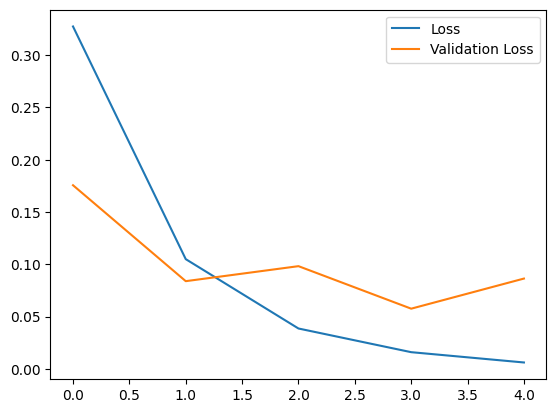

In [30]:
# Loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

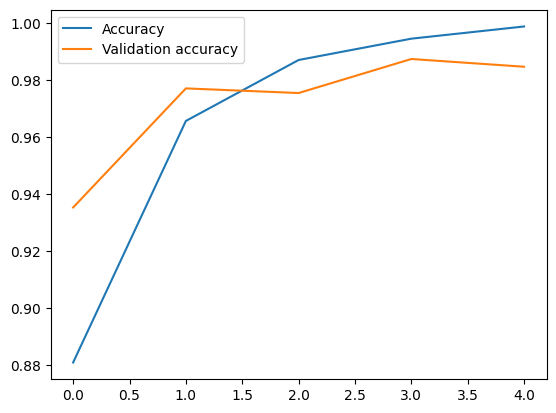

In [31]:
# Accuracy per iteration
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation accuracy')
plt.legend()
plt.show()

## 3. Building the RNN model

In [32]:
# Choose embedding dimensionality
D = 20  # this is a hyper parameter, we can choose any word vector size that we want

# Hidden state vectorsize (dimensionality)
M = 15

# Input layer
i = Input(shape=(T,))  # input layer takes in sequences of integers, so shape is T

# Embedding layer
x = Embedding(V + 1, D)(i) # This takes in sequences of integers and returns sequences of word vectors
# This will be an N * T * D array
# we want size of embedding to (V + 1) x D, because first word index starts from 1 and not 0

# LSTM layer
x = LSTM(M, return_sequences=True)(x)
x = GlobalMaxPooling1D()(x)

# Dense layer
x = Dense(1, activation='sigmoid')(x)
# it is an binary classification problem, so we are using activation function ='sigmoid'

model = Model(i, x)


In [33]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [34]:
# Train the model
r = model.fit(x=data_train, y=y_train, epochs=10, validation_data=(data_test, y_test))

Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.8644 - loss: 0.4911 - val_accuracy: 0.8575 - val_loss: 0.2866
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.8942 - loss: 0.2221 - val_accuracy: 0.9744 - val_loss: 0.1176
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9843 - loss: 0.0871 - val_accuracy: 0.9837 - val_loss: 0.0746
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.9926 - loss: 0.0511 - val_accuracy: 0.9864 - val_loss: 0.0633
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9955 - loss: 0.0313 - val_accuracy: 0.9886 - val_loss: 0.0559
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - accuracy: 0.9971 - loss: 0.0212 - val_accuracy: 0.9875 - val_loss: 0.0552
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.9986 - loss: 0.0148 - val_accuracy: 0.9875 - val_loss: 0.0552
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.9985 - loss: 0.0

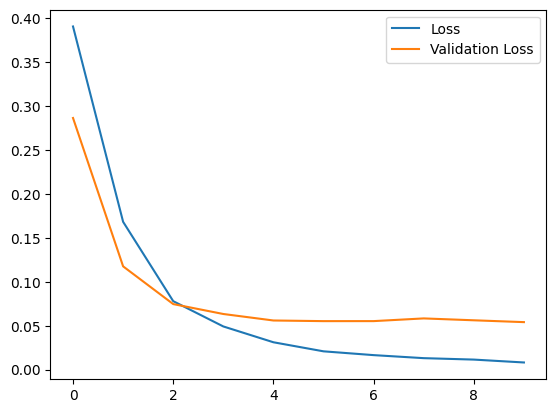

In [35]:
# Loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

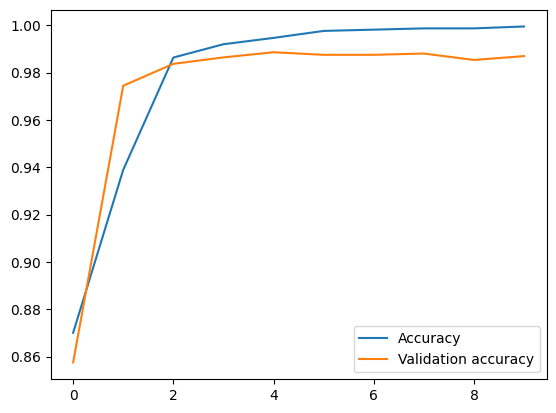

In [36]:
# Accuracy per iteration
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation accuracy')
plt.legend()
plt.show()